  Model      mean       std  Model_num
0     1  0.721715  0.264537          1
3     2  0.984748  0.039837          2
6     4  0.989386  0.021624          4
9     8  0.980757  0.030624          8
2    16  0.968121  0.031907         16
5    32  0.996809  0.002637         32
8    64  0.995844  0.002717         64
1   128  0.994541  0.005182        128
4   256  0.993340  0.004432        256
7   512  0.991123  0.007242        512


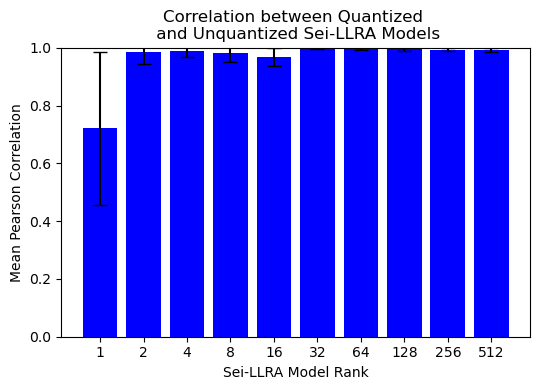

In [5]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

# Load the pickle file
with open("sei_pearson_corrs_shuffle_quant.pkl", "rb") as f:
    data = pickle.load(f)

# Convert to DataFrame
df_list = []
for model_name, corrs in data.items():
    for corr in corrs:
        df_list.append({"Model": str(model_name), "Correlation": corr})

df = pd.DataFrame(df_list)

# Aggregate mean and std for bar plot
summary_df = df.groupby("Model")["Correlation"].agg(["mean", "std"]).reset_index()

# Convert model names to numeric and sort
summary_df["Model_num"] = summary_df["Model"].astype(int)
summary_df = summary_df.sort_values("Model_num")

# Plot
plt.figure(figsize=(5.5, 4))
plt.bar(
    summary_df["Model_num"].astype(str),  # x-axis as string labels
    summary_df["mean"], 
    yerr=summary_df["std"], 
    capsize=5,
    color="blue"  # same color for all bars
)
plt.ylim(0, 1)
plt.ylabel("Mean Pearson Correlation")
plt.xlabel("Sei-LLRA Model Rank")
plt.title("Correlation between Quantized \n and Unquantized Sei-LLRA Models")
# plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("../figs/fig3b_quant_noquant_ccre_corr.png", dpi=300)

print(summary_df)

Column names being used:
Sei-LLRA: ['GTEX_eqtl_OvU_promoter', 'GTEX_eqtl_outliers_OvU_promoter', 'CAGI5_saturation_OvU_promoter', 'MPRA_saturation_OvU_promoter', 'MPRA_eqtl_OvU_promoter', 'UKBB_proteome_OvU_promoter', 'Gel_RNA_OvU_promoter']
Borzoi-LLRA: ['GTEX_eqtl_OvU_promoter', 'GTEX_eqtl_outliers_OvU_promoter', 'CAGI5_saturation_OvU_promoter', 'MPRA_saturation_OvU_promoter', 'MPRA_eqtl_OvU_promoter', 'UKBB_proteome_OvU_promoter', 'Gel_RNA_OvU_promoter']
Enformer-LLRA: ['GTEX_eqtl_OvU_promoter', 'GTEX_eqtl_outliers_OvU_promoter', 'CAGI5_saturation_OvU_promoter', 'MPRA_saturation_OvU_promoter', 'MPRA_eqtl_OvU_promoter', 'UKBB_proteome_OvU_promoter', 'Gel_RNA_OvU_promoter']

Sei-LLRA - Loaded 260 rows
After filtering contaminated: 260 rows
Runtime lookup added: seilora_1_None_no_quant -> 2.21 min/100seq
Runtime lookup added: seilora_1024_None_no_quant -> 2.31 min/100seq
Runtime lookup added: seilora_128_None_no_quant -> 2.23 min/100seq
Runtime lookup added: seilora_16_None_no_quant ->

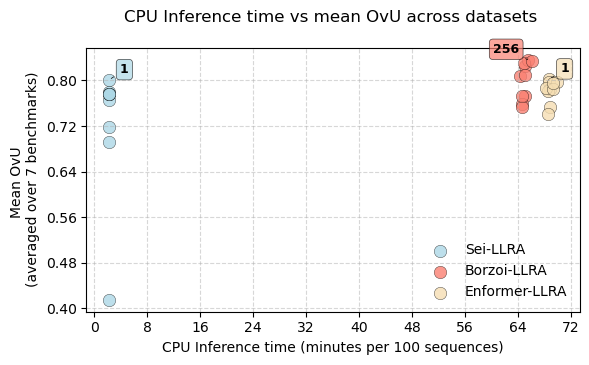


Plot saved to ../figs/fig2_runtime_vs_auroc.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# plot mean AUROC vs CPU inference runtime per model (one runtime file per model type)
runtime_files = {
    "Sei-LLRA": "sei_count_times.csv",
    "Borzoi-LLRA": "borzoi_count_times.csv",
    "Enformer-LLRA": "enformer_count_times.csv"
}

points = {
    "Sei-LLRA": [], "Borzoi-LLRA": [], "Enformer-LLRA": [],
    "Sei": [], "Borzoi": [], "Enformer": []
}
group_colors = {
    "Sei-LLRA": "lightblue", "Borzoi-LLRA": "salmon", "Enformer-LLRA": "wheat",
    "Sei": "blue", "Borzoi": "orangered", "Enformer": "orange"
}

seilora_model_names = {
    "seilora_1_None_no_quant": "Sei-LLRA\nrank=1",
    "seilora_2_None_no_quant": "Sei-LLRA\nrank=2",
    "seilora_4_None_no_quant": "Sei-LLRA\nrank=4",
    "seilora_8_None_no_quant": "Sei-LLRA\nrank=8",
    "seilora_16_None_no_quant": "Sei-LLRA\nrank=16",
    "seilora_32_None_no_quant": "Sei-LLRA\nrank=32",
    "seilora_64_None_no_quant": "Sei-LLRA\nrank=64",
    "seilora_128_None_no_quant": "Sei-LLRA\nrank=128",
    "seilora_256_None_no_quant": "Sei-LLRA\nrank=256",
    "seilora_512_None_no_quant": "Sei-LLRA\nrank=512",
    "seilora_full_None_no_quant": "Sei",
}
borzoilora_model_names = {
    "borzoi_lora_lr1_crfull_None_no_quant": "Borzoi-LLRA\nrank=1",
    "borzoi_lora_lr2_crfull_None_no_quant": "Borzoi-LLRA\nrank=2",
    "borzoi_lora_lr4_crfull_None_no_quant": "Borzoi-LLRA\nrank=4",
    "borzoi_lora_lr8_crfull_None_no_quant": "Borzoi-LLRA\nrank=8",
    "borzoi_lora_lr16_crfull_None_no_quant": "Borzoi-LLRA\nrank=16",
    "borzoi_lora_lr32_crfull_None_no_quant": "Borzoi-LLRA\nrank=32",
    "borzoi_lora_lr64_crfull_None_no_quant": "Borzoi-LLRA\nrank=64",
    "borzoi_lora_lr128_crfull_None_no_quant": "Borzoi-LLRA\nrank=128",
    "borzoi_lora_lr256_crfull_None_no_quant": "Borzoi-LLRA\nrank=256",
    "borzoi_lora_lr512_crfull_None_no_quant": "Borzoi-LLRA\nrank=512",
    "borzoi_lora_lrfull_crfull_None_no_quant": "Borzoi",
}
enformerlora_model_names = {
    "enformer_lora_lr1_crfull_None_no_quant": "Enformer-LLRA\nrank=1",
    "enformer_lora_lr2_crfull_None_no_quant": "Enformer-LLRA\nrank=2",
    "enformer_lora_lr4_crfull_None_no_quant": "Enformer-LLRA\nrank=4",
    "enformer_lora_lr8_crfull_None_no_quant": "Enformer-LLRA\nrank=8",
    "enformer_lora_lr16_crfull_None_no_quant": "Enformer-LLRA\nrank=16",
    "enformer_lora_lr32_crfull_None_no_quant": "Enformer-LLRA\nrank=32",
    "enformer_lora_lr64_crfull_None_no_quant": "Enformer-LLRA\nrank=64",
    "enformer_lora_lr128_crfull_None_no_quant": "Enformer-LLRA\nrank=128",
    "enformer_lora_lr256_crfull_None_no_quant": "Enformer-LLRA\nrank=256",
    "enformer_lora_lr512_crfull_None_no_quant": "Enformer-LLRA\nrank=512",
    "enformer_lora_lrfull_crfull_None_no_quant": "Enformer",
}

metrics = {"OvU": "Over vs Under",
           "UvN": "Under vs None",
           "OvN": "Over vs None"
           }

# FIXED: Updated to match actual column names
caqtl_datasets = {
    "D": "GTEX_eqtl",
    "A": "GTEX_eqtl_outliers",
    "B": "CAGI5_saturation",
    "C": "MPRA_saturation",
    "E": "MPRA_eqtl",
    "F": "UKBB_proteome",
    "G": "Gel_RNA"
}

dataset_order = ["D", "A", "B", "C", "E", "F", "G"]

files = {
    "Sei-LLRA": "benchmark_pai_seilora.tsv",
    "Borzoi-LLRA": "borzoi_fixed_benchmark_promoterai.tsv",
    "Enformer-LLRA": "enformer_fixed_benchmark_promoterai.tsv",
}

# Read benchmark data
dfs = {}
for model_name, file in files.items():
    df = pd.read_csv(file, sep="\t", index_col=0, header=0)
    for row_name in df.index:
        if (
            row_name not in seilora_model_names
            and row_name not in borzoilora_model_names
            and row_name not in enformerlora_model_names
        ):
            # remove from dataframe
            df = df.drop(row_name)
    dfs[model_name] = df

# Create metric_cols_per_df mapping
# FIXED: Use actual column name format: {dataset}_{metric}_promoter
metric_key = "OvU"  # change if you want OvN or UvN
metric_cols_per_df = {}

for source_name in ["Sei-LLRA", "Borzoi-LLRA", "Enformer-LLRA"]:
    # Construct column names matching the actual format
    metric_cols_per_df[source_name] = [f"{caqtl_datasets[ds]}_{metric_key}_promoter" for ds in dataset_order]

print("Column names being used:")
for source_name, cols in metric_cols_per_df.items():
    print(f"{source_name}: {cols}")

# Read runtimes and compute mean across all runs for each model/rank
runtime_lookup = {}

for model_source, path in runtime_files.items():
    try:
        df_runtimes = pd.read_csv(path, sep=",", header=None)
        # CSV has no header: model, rank, iteration, forward_time_ms, other_cpu_avg_usage, other_cpu_max_usage, contaminated
        df_runtimes.columns = ['model', 'rank', 'iteration', 'forward_time_ms', 'other_cpu_avg_usage', 'other_cpu_max_usage', 'contaminated']
        
        print(f"\n{model_source} - Loaded {len(df_runtimes)} rows")
        
    except Exception as e:
        print(f"Warning: couldn't read runtime file {path}: {e}")
        continue

    # Filter out contaminated runs if you want
    df_runtimes = df_runtimes[df_runtimes['contaminated'] == False]
    print(f"After filtering contaminated: {len(df_runtimes)} rows")

    if model_source == "Sei-LLRA":
        # Group by rank and take mean of forward_time_ms across all iterations
        grouped = df_runtimes.groupby('rank')['forward_time_ms'].mean()
        
        for rank, time_ms in grouped.items():
            # Convert ms per 1 sequence to minutes per 100 sequences
            time_minutes_per_100 = (time_ms / 1000 / 60) * 100
            key = f"seilora_{rank}_None_no_quant"
            runtime_lookup[str(key)] = float(time_minutes_per_100)
            print(f"Runtime lookup added: {key} -> {time_minutes_per_100:.2f} min/100seq")
    
    elif model_source == "Borzoi-LLRA":
        # Group by model and rank, take mean of forward_time_ms
        grouped = df_runtimes.groupby(['model', 'rank'])['forward_time_ms'].mean()
        
        for (model, rank), time_ms in grouped.items():
            # Convert ms per 1 sequence to minutes per 100 sequences
            time_minutes_per_100 = (time_ms / 1000 / 60) * 100
            key = f"{model}_lora_lr{rank}_crfull_None_no_quant"
            runtime_lookup[str(key)] = float(time_minutes_per_100)
            print(f"Runtime lookup added: {key} -> {time_minutes_per_100:.2f} min/100seq")
    
    elif model_source == "Enformer-LLRA":
        # Group by model and rank, take mean of forward_time_ms
        grouped = df_runtimes.groupby(['model', 'rank'])['forward_time_ms'].mean()
        
        for (model, rank), time_ms in grouped.items():
            # Convert ms per 1 sequence to minutes per 100 sequences
            time_minutes_per_100 = (time_ms / 1000 / 60) * 100
            key = f"{model}_lora_lr{rank}_crfull_None_no_quant"
            runtime_lookup[str(key)] = float(time_minutes_per_100)
            print(f"Runtime lookup added: {key} -> {time_minutes_per_100:.2f} min/100seq")

print("\n" + "="*50)
print("Runtime lookup complete")
print("="*50 + "\n")

# Collect (runtime, mean_auroc, group_label, row_name) for LoRA models only
points_runtime = {
    "Sei-LLRA": [], "Borzoi-LLRA": [], "Enformer-LLRA": []
}

# Use same color groups as for size plot
group_colors_runtime = {
    "Sei-LLRA": group_colors.get("Sei-LLRA", "lightblue"),
    "Borzoi-LLRA": group_colors.get("Borzoi-LLRA", "salmon"),
    "Enformer-LLRA": group_colors.get("Enformer-LLRA", "wheat")
}

# Iterate over dfs for each source and assign points to LoRA models only
for source_name, df_model in dfs.items():
    metric_cols = metric_cols_per_df[source_name]

    if source_name == "Sei-LLRA":
        name_map = seilora_model_names
        base_label = "Sei-LLRA"
    elif source_name == "Borzoi-LLRA":
        name_map = borzoilora_model_names
        base_label = "Borzoi-LLRA"
    else:
        name_map = enformerlora_model_names
        base_label = "Enformer-LLRA"

    for row_name in df_model.index:
        # Detect full (non-LoRA) models first and skip them
        rl = row_name.lower()
        mapped_label = str(name_map.get(row_name, "")).lower()
        is_full = ("lrfull" in rl) or ("_full" in rl) or ("rank=full" in mapped_label) or ("full" in rl and "crfull" not in rl)
        if is_full:
            print(f"Skipping full model: {row_name}")
            continue  # skip full models
        
        # Find runtime (exact match or fuzzy containment)
        runtime = runtime_lookup.get(row_name)
        if runtime is None:
            match = next((k for k in runtime_lookup if k in row_name or row_name in k), None)
            runtime = runtime_lookup.get(match) if match is not None else None
        if runtime is None:
            print(f"Warning: No runtime found for {row_name} - skipping")
            continue

        # Compute mean AUROC across the 7 datasets for the chosen metric
        scores = df_model.loc[row_name, metric_cols].astype(float)
        mean_auroc = float(scores.mean())

        # Store (runtime, mean_auroc, row_name) to track which has highest AUROC
        points_runtime[base_label].append((runtime, mean_auroc, row_name))
        print(f"Added point: {row_name} -> runtime={runtime:.2f}, mean_auroc={mean_auroc:.4f}")

print("\n" + "="*50)
print("Point collection complete")
print("="*50 + "\n")

# Extract rank from model name
def extract_rank(row_name):
    """Extract rank number from model name"""
    import re
    # Try patterns like "lr512", "512", "_512_"
    patterns = [r'lr(\d+)', r'_(\d+)_', r'rank(\d+)']
    for pattern in patterns:
        match = re.search(pattern, row_name)
        if match:
            return int(match.group(1))
    return 0

# Create figure/axis
fig3, ax_c3 = plt.subplots(figsize=(6, 3.75))
seen = set()

for group_label, pts in points_runtime.items():
    if not pts:
        print(f"Warning: No points for {group_label}")
        continue
    
    # Separate coordinates and row names
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    row_names = [p[2] for p in pts]
    
    color = group_colors_runtime.get(group_label, "gray")
    plot_label = group_label if group_label not in seen else None
    seen.add(group_label)
    ax_c3.scatter(xs, ys, color=color, s=80, label=plot_label, alpha=0.8, edgecolor="k", linewidth=0.3)
    
    # Find the point with the highest y-axis value (highest AUROC)
    max_auroc_idx = ys.index(max(ys))
    max_x, max_y = xs[max_auroc_idx], ys[max_auroc_idx]
    max_rank = extract_rank(row_names[max_auroc_idx])
    
    # Set offset based on group - Borzoi goes left, others go right
    if group_label == "Borzoi-LLRA":
        offset = (-25, 5)  # Left of the point
    else:
        offset = (8, 5)    # Right of the point (default)
    
    # Annotate the highest AUROC point
    ax_c3.annotate(f'{max_rank}', 
                   xy=(max_x, max_y), 
                   xytext=offset, 
                   textcoords='offset points',
                   fontsize=9,
                   fontweight='bold',
                   color='black',
                   bbox=dict(boxstyle='round,pad=0.3', facecolor=color, edgecolor='black', linewidth=0.5, alpha=0.7),
                   arrowprops=dict(arrowstyle='-', connectionstyle='arc3,rad=0', lw=0.5, color='black'))

# Aesthetics
ax_c3.set_xlabel("CPU Inference time (minutes per 100 sequences)")
ax_c3.set_ylabel(f"Mean {metric_key} \n(averaged over {len(dataset_order)} benchmarks)")
ax_c3.set_title(f"CPU Inference time vs mean {metric_key} across datasets \n", fontsize=12)
ax_c3.legend(frameon=False, fontsize=10, loc="lower right")
ax_c3.grid(True, linestyle="--", alpha=0.5)

# Format axes to use whole numbers
from matplotlib.ticker import MaxNLocator
ax_c3.xaxis.set_major_locator(MaxNLocator(integer=True))
ax_c3.yaxis.set_major_locator(MaxNLocator(nbins=6))  # Reasonable number of y-axis ticks

plt.tight_layout()
plt.savefig('../figs/fig2_runtime_vs_auroc.png', dpi=300)
plt.show()

print(f"\nPlot saved to ../figs/fig2_runtime_vs_auroc.png")

Loading QUANTIZED models

Sei (quant) - Loaded 260 rows
After filtering contaminated: 260 rows

Borzoi (quant) - Loaded 220 rows
After filtering contaminated: 220 rows

Enformer (quant) - Loaded 220 rows
After filtering contaminated: 220 rows

Loading NON-QUANTIZED models

Sei (noquant) - Loaded 260 rows
After filtering contaminated: 260 rows

Borzoi (noquant) - Loaded 206 rows
After filtering contaminated: 206 rows

Enformer (noquant) - Loaded 220 rows
After filtering contaminated: 220 rows

Runtime data collected:

Quantized:
  Sei: {1: 0.338910155, 1024: 0.34624272, 128: 0.339418545, 16: 0.338861455, 2: 0.34052631, 2048: 0.36068335, 256: 0.34192528000000005, 32: 0.339444515, 4: 0.33925814000000004, 512: 0.344415115, 64: 0.33931934999999996, 8: 0.33893072999999996, 'full': 1.86645488}
  Borzoi: {1: 38.636032795, 128: 39.103016535, 16: 39.062149845, 2: 38.778433750000005, 256: 39.317468715000004, 32: 39.08835046, 4: 38.80370665, 512: 39.712540665, 64: 38.98678661500001, 8: 38.81559932

/var/folders/m7/dmsq22ys4vdbpb0j27w6prv40000gn/T/ipykernel_82918/4094719472.py:288: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax1.set_ylim(0, 100)


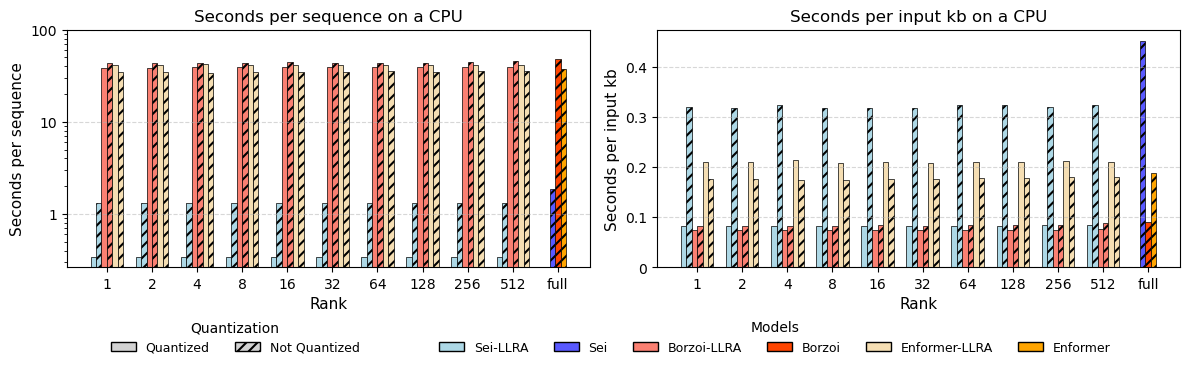


Bar plots saved to ../figs/fig_runtime_barplots_quant_comparison.png

SUMMARY STATISTICS

Seconds per sequence:

Sei:
  Rank 1: quant=0.339s, noquant=1.314s, speedup=3.88x (quant faster)
  Rank 2: quant=0.341s, noquant=1.305s, speedup=3.83x (quant faster)
  Rank 4: quant=0.339s, noquant=1.329s, speedup=3.92x (quant faster)
  Rank 8: quant=0.339s, noquant=1.307s, speedup=3.86x (quant faster)
  Rank 16: quant=0.339s, noquant=1.308s, speedup=3.86x (quant faster)
  Rank 32: quant=0.339s, noquant=1.305s, speedup=3.84x (quant faster)
  Rank 64: quant=0.339s, noquant=1.326s, speedup=3.91x (quant faster)
  Rank 128: quant=0.339s, noquant=1.326s, speedup=3.91x (quant faster)
  Rank 256: quant=0.342s, noquant=1.315s, speedup=3.85x (quant faster)
  Rank 512: quant=0.344s, noquant=1.331s, speedup=3.86x (quant faster)
  Rank full: quant=1.866s, noquant=1.854s, speedup=0.99x (noquant faster)

Borzoi:
  Rank 1: quant=38.636s, noquant=43.534s, speedup=1.13x (quant faster)
  Rank 2: quant=38.778s, noq

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.ticker import FuncFormatter

# Runtime files - quantized
runtime_files_quant = {
    "Sei": "sei_count_times.csv",
    "Borzoi": "borzoi_count_times.csv",
    "Enformer": "enformer_count_times.csv"
}

# Runtime files - non-quantized
runtime_files_noquant = {
    "Sei": "sei_count_times_noquant.csv",
    "Borzoi": "borzoi_count_times_noquant.csv",
    "Enformer": "enformer_count_times_noquant.csv"
}

# Colors for LLRA models (used for all ranks except 'full')
llra_colors = {
    "Sei": "lightblue",
    "Borzoi": "salmon",
    "Enformer": "wheat"
}

# Full model colors (darker versions, used for 'full' rank)
full_colors = {
    "Sei": "#0000FFA6",
    "Borzoi": "orangered",
    "Enformer": "orange"
}

def load_runtime_data(runtime_files, label=""):
    """Load runtime data from CSV files."""
    runtime_data = {
        "Sei": {},
        "Borzoi": {},
        "Enformer": {}
    }
    
    for model_name, path in runtime_files.items():
        try:
            # Try reading with header first (for Sei which has header)
            df_test = pd.read_csv(path, sep=",", nrows=1, header=None)
            first_val = str(df_test.iloc[0, 0]).lower()
            
            if first_val == 'model':
                # Has header row
                df_runtimes = pd.read_csv(path, sep=",")
            else:
                # No header row
                df_runtimes = pd.read_csv(path, sep=",", header=None)
                df_runtimes.columns = ['model', 'rank', 'iteration', 'forward_time_ms', 
                                        'other_cpu_avg_usage', 'other_cpu_max_usage', 'contaminated']
            
            print(f"\n{model_name} {label} - Loaded {len(df_runtimes)} rows")
            
        except Exception as e:
            print(f"Warning: couldn't read runtime file {path}: {e}")
            continue

        # Convert contaminated column to proper boolean
        df_runtimes['contaminated'] = df_runtimes['contaminated'].astype(str).str.lower() == 'true'
        
        # Filter out contaminated runs
        df_runtimes = df_runtimes[df_runtimes['contaminated'] == False]
        print(f"After filtering contaminated: {len(df_runtimes)} rows")

        # Ensure forward_time_ms is numeric
        df_runtimes['forward_time_ms'] = pd.to_numeric(df_runtimes['forward_time_ms'], errors='coerce')

        # Group by rank and take mean of forward_time_ms across all iterations
        if 'model' in df_runtimes.columns and df_runtimes['model'].nunique() > 1:
            grouped = df_runtimes.groupby(['model', 'rank'])['forward_time_ms'].mean()
            for (model, rank), time_ms in grouped.items():
                time_seconds = time_ms / 1000
                if rank == "full":
                    runtime_data[model_name]["full"] = time_seconds
                else:
                    try:
                        runtime_data[model_name][int(rank)] = time_seconds
                    except (ValueError, TypeError):
                        runtime_data[model_name][rank] = time_seconds
        else:
            grouped = df_runtimes.groupby('rank')['forward_time_ms'].mean()
            for rank, time_ms in grouped.items():
                time_seconds = time_ms / 1000
                if rank == "full":
                    runtime_data[model_name]["full"] = time_seconds
                else:
                    try:
                        runtime_data[model_name][int(rank)] = time_seconds
                    except (ValueError, TypeError):
                        runtime_data[model_name][rank] = time_seconds
    
    return runtime_data

# Load both quantized and non-quantized data
print("=" * 60)
print("Loading QUANTIZED models")
print("=" * 60)
runtime_data_quant = load_runtime_data(runtime_files_quant, "(quant)")

print("\n" + "=" * 60)
print("Loading NON-QUANTIZED models")
print("=" * 60)
runtime_data_noquant = load_runtime_data(runtime_files_noquant, "(noquant)")

print("\n" + "=" * 60)
print("Runtime data collected:")
print("=" * 60)
print("\nQuantized:")
for model, ranks in runtime_data_quant.items():
    print(f"  {model}: {ranks}")
print("\nNon-quantized:")
for model, ranks in runtime_data_noquant.items():
    print(f"  {model}: {ranks}")

# Define sequence lengths in kb for each model
sequence_lengths_kb = {
    "Sei-LLRA": 4.096,
    "Borzoi-LLRA": 524.288,
    "Enformer-LLRA": 196.608,
    "Sei": 4.096,
    "Borzoi": 524.288,
    "Enformer": 196.608
}

# Get all unique ranks across all models (both quant and noquant)
all_ranks = set()
for model_data in runtime_data_quant.values():
    all_ranks.update(model_data.keys())
for model_data in runtime_data_noquant.values():
    all_ranks.update(model_data.keys())

# Exclude ranks 1024 and 2048
all_ranks = {r for r in all_ranks if r not in [1024, 2048]}

# Sort ranks (numeric first, then 'full')
numeric_ranks = sorted([r for r in all_ranks if isinstance(r, int)])
if "full" in all_ranks:
    rank_labels = numeric_ranks + ["full"]
else:
    rank_labels = numeric_ranks

print(f"\nRank labels (excluding 1024 and 2048): {rank_labels}")

# Prepare data for plotting
# Order: Sei-quant, Sei-noquant, Borzoi-quant, Borzoi-noquant, Enformer-quant, Enformer-noquant
models = ["Sei", "Borzoi", "Enformer"]
n_ranks = len(rank_labels)
n_bars_per_rank = 6  # 3 models × 2 (quant + noquant)

# Data for plot 1: seconds per sequence
# Structure: list of (data, color, hatch, label) for each bar type
bar_configs = []
for model in models:
    # Quantized
    quant_data = []
    for rank in rank_labels:
        time_val = runtime_data_quant[model].get(rank, 0)
        quant_data.append(time_val)
    bar_configs.append({
        'data': quant_data,
        'model': model,
        'quant': True,
        'label': f'{model} (quant)'
    })
    
    # Non-quantized
    noquant_data = []
    for rank in rank_labels:
        time_val = runtime_data_noquant[model].get(rank, 0)
        noquant_data.append(time_val)
    bar_configs.append({
        'data': noquant_data,
        'model': model,
        'quant': False,
        'label': f'{model} (no quant)'
    })

# Data for plot 2: seconds per kb
bar_configs_kb = []
for model in models:
    seq_len_kb = sequence_lengths_kb[model]
    
    # Quantized
    quant_data = []
    for rank in rank_labels:
        time_val = runtime_data_quant[model].get(rank, 0)
        time_per_kb = time_val / seq_len_kb if seq_len_kb > 0 else 0
        quant_data.append(time_per_kb)
    bar_configs_kb.append({
        'data': quant_data,
        'model': model,
        'quant': True,
        'label': f'{model} (quant)'
    })
    
    # Non-quantized
    noquant_data = []
    for rank in rank_labels:
        time_val = runtime_data_noquant[model].get(rank, 0)
        time_per_kb = time_val / seq_len_kb if seq_len_kb > 0 else 0
        noquant_data.append(time_per_kb)
    bar_configs_kb.append({
        'data': noquant_data,
        'model': model,
        'quant': False,
        'label': f'{model} (no quant)'
    })

# Create bar plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5))

# Set hatch color to white globally
plt.rcParams['hatch.color'] = 'white'
plt.rcParams['hatch.linewidth'] = 1.5

# Setup for grouped bars
x = np.arange(n_ranks)
width = 0.12  # Width of each bar (narrower to fit 6 bars)

# Offsets for regular ranks (6 bars: 3 models × 2 quant/noquant)
offsets_regular = np.array([-2.5, -1.5, -0.5, 0.5, 1.5, 2.5]) * width

# Offsets for 'full' rank (3 bars: 3 models × noquant only)
offsets_full = np.array([-1, 0, 1]) * width

# Find index of 'full' rank
full_idx = rank_labels.index("full") if "full" in rank_labels else -1

# Plot 1: Seconds per sequence
for i, config in enumerate(bar_configs):
    model = config['model']
    is_quant = config['quant']
    data = config['data']
    
    # Skip quantized data for 'full' rank
    if is_quant:
        # Set 'full' rank data to 0 (won't be plotted)
        data = [d if rank != "full" else 0 for d, rank in zip(data, rank_labels)]
    
    # Determine colors for each rank (different for 'full')
    colors = []
    for rank in rank_labels:
        if rank == "full":
            colors.append(full_colors[model])
        else:
            colors.append(llra_colors[model])
    
    # Hatch pattern for non-quantized (white hatches)
    hatch = None if is_quant else '///'
    
    # Calculate positions - different for 'full' rank
    positions = []
    for j, rank in enumerate(rank_labels):
        if rank == "full":
            if is_quant:
                # Quantized bars not shown for 'full', position doesn't matter
                positions.append(x[j])
            else:
                # Non-quantized: use compact offsets for 'full'
                # Map model to offset: Sei=0, Borzoi=1, Enformer=2
                model_idx = models.index(model)
                positions.append(x[j] + offsets_full[model_idx])
        else:
            # Regular ranks use standard offsets
            positions.append(x[j] + offsets_regular[i])
    
    positions = np.array(positions)
    
    # Only plot non-zero values
    mask = np.array(data) > 0
    if np.any(mask):
        bars = ax1.bar(positions[mask], np.array(data)[mask], width,
                       color=[colors[j] for j in range(len(colors)) if mask[j]],
                       edgecolor='black', 
                       linewidth=0.5,
                       hatch=hatch)

ax1.set_xlabel('Rank', fontsize=11)
ax1.set_ylabel('Seconds per sequence', fontsize=11)
ax1.set_title('Seconds per sequence on a CPU', fontsize=12)
ax1.set_yscale("log")
ax1.set_ylim(0, 100)
ax1.set_xticks(x)
ax1.set_xticklabels(rank_labels, rotation=0, ha='center')
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.10g}'))

# Plot 2: Seconds per kb
for i, config in enumerate(bar_configs_kb):
    model = config['model']
    is_quant = config['quant']
    data = config['data']
    
    # Skip quantized data for 'full' rank
    if is_quant:
        # Set 'full' rank data to 0 (won't be plotted)
        data = [d if rank != "full" else 0 for d, rank in zip(data, rank_labels)]
    
    # Determine colors for each rank (different for 'full')
    colors = []
    for rank in rank_labels:
        if rank == "full":
            colors.append(full_colors[model])
        else:
            colors.append(llra_colors[model])
    
    # Hatch pattern for non-quantized (white hatches)
    hatch = None if is_quant else '///'
    
    # Calculate positions - different for 'full' rank
    positions = []
    for j, rank in enumerate(rank_labels):
        if rank == "full":
            if is_quant:
                # Quantized bars not shown for 'full', position doesn't matter
                positions.append(x[j])
            else:
                # Non-quantized: use compact offsets for 'full'
                model_idx = models.index(model)
                positions.append(x[j] + offsets_full[model_idx])
        else:
            # Regular ranks use standard offsets
            positions.append(x[j] + offsets_regular[i])
    
    positions = np.array(positions)
    
    # Only plot non-zero values
    mask = np.array(data) > 0
    if np.any(mask):
        bars = ax2.bar(positions[mask], np.array(data)[mask], width,
                       color=[colors[j] for j in range(len(colors)) if mask[j]],
                       edgecolor='black',
                       linewidth=0.5,
                       hatch=hatch)

ax2.set_xlabel('Rank', fontsize=11)
ax2.set_ylabel('Seconds per input kb', fontsize=11)
ax2.set_title('Seconds per input kb on a CPU', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(rank_labels, rotation=0, ha='center')
ax2.grid(True, axis='y', linestyle='--', alpha=0.5)
ax2.ticklabel_format(style='plain', axis='y')
#ax2.set_yscale("log")
#ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{y:.10g}'))

# Create custom legend
# legend_elements = [
#     Patch(facecolor=llra_colors['Sei'], edgecolor='black', label='Sei-LLRA (quant)'),
#     Patch(facecolor=llra_colors['Sei'], edgecolor='black', hatch='///', label='Sei-LLRA (no quant)'),
#     Patch(facecolor=full_colors['Sei'], edgecolor='black', hatch='///', label='Sei (full)'),
#     Patch(facecolor=llra_colors['Borzoi'], edgecolor='black', label='Borzoi-LLRA (quant)'),
#     Patch(facecolor=llra_colors['Borzoi'], edgecolor='black', hatch='///', label='Borzoi-LLRA (no quant)'),
#     Patch(facecolor=full_colors['Borzoi'], edgecolor='black', hatch='///', label='Borzoi (full)'),
#     Patch(facecolor=llra_colors['Enformer'], edgecolor='black', label='Enformer-LLRA (quant)'),
#     Patch(facecolor=llra_colors['Enformer'], edgecolor='black', hatch='///', label='Enformer-LLRA (no quant)'),
#     Patch(facecolor=full_colors['Enformer'], edgecolor='black', hatch='///', label='Enformer (full)'),
# ]

# fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, -0.12),
#            ncol=3, frameon=False, fontsize=9)

quant_legend_elements = [
    Patch(facecolor='lightgrey', edgecolor='black', label='Quantized'),
    Patch(facecolor='lightgrey', edgecolor='black', hatch='///', label='Not Quantized'),
]

model_legend_elements = [
    Patch(facecolor=llra_colors['Sei'], edgecolor='black', label='Sei-LLRA'),
    Patch(facecolor=full_colors['Sei'], edgecolor='black', label='Sei'),
    Patch(facecolor=llra_colors['Borzoi'], edgecolor='black', label='Borzoi-LLRA'),
    Patch(facecolor=full_colors['Borzoi'], edgecolor='black', label='Borzoi'),
    Patch(facecolor=llra_colors['Enformer'], edgecolor='black', label='Enformer-LLRA'),
    Patch(facecolor=full_colors['Enformer'], edgecolor='black', label='Enformer'),
]

# Add both legends
quant_legend = fig.legend(handles=quant_legend_elements, loc='lower center', 
                          bbox_to_anchor=(0.2, -0.06), ncol=2, frameon=False, 
                          fontsize=9, title='Quantization')
model_legend = fig.legend(handles=model_legend_elements, loc='lower center', 
                          bbox_to_anchor=(0.65, -0.06), ncol=6, frameon=False, 
                          fontsize=9, title='Models')

# Add the first legend back to the figure (second legend call removes the first)

plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
plt.savefig('../figs/fig_runtime_barplots_quant_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nBar plots saved to ../figs/fig_runtime_barplots_quant_comparison.png")

# Print summary statistics
print("\n" + "=" * 60)
print("SUMMARY STATISTICS")
print("=" * 60)

print("\nSeconds per sequence:")
for model in models:
    print(f"\n{model}:")
    for j, rank in enumerate(rank_labels):
        quant_val = runtime_data_quant[model].get(rank, 0)
        noquant_val = runtime_data_noquant[model].get(rank, 0)
        if quant_val > 0 and noquant_val > 0:
            speedup = noquant_val / quant_val
            faster = "quant" if speedup > 1 else "noquant"
            print(f"  Rank {rank}: quant={quant_val:.3f}s, noquant={noquant_val:.3f}s, speedup={speedup:.2f}x ({faster} faster)")
        else:
            print(f"  Rank {rank}: quant={quant_val:.3f}s, noquant={noquant_val:.3f}s")

print("\n" + "=" * 60)
print("QUANTIZATION SPEEDUP SUMMARY")
print("=" * 60)
for model in models:
    print(f"\n{model}:")
    speedups = []
    for rank in rank_labels:
        quant_val = runtime_data_quant[model].get(rank, 0)
        noquant_val = runtime_data_noquant[model].get(rank, 0)
        if quant_val > 0 and noquant_val > 0:
            speedup = noquant_val / quant_val
            speedups.append(speedup)
    if speedups:
        avg_speedup = np.mean(speedups)
        if avg_speedup > 1:
            print(f"  Average speedup from quantization: {avg_speedup:.2f}x FASTER")
        else:
            print(f"  Average slowdown from quantization: {1/avg_speedup:.2f}x SLOWER")

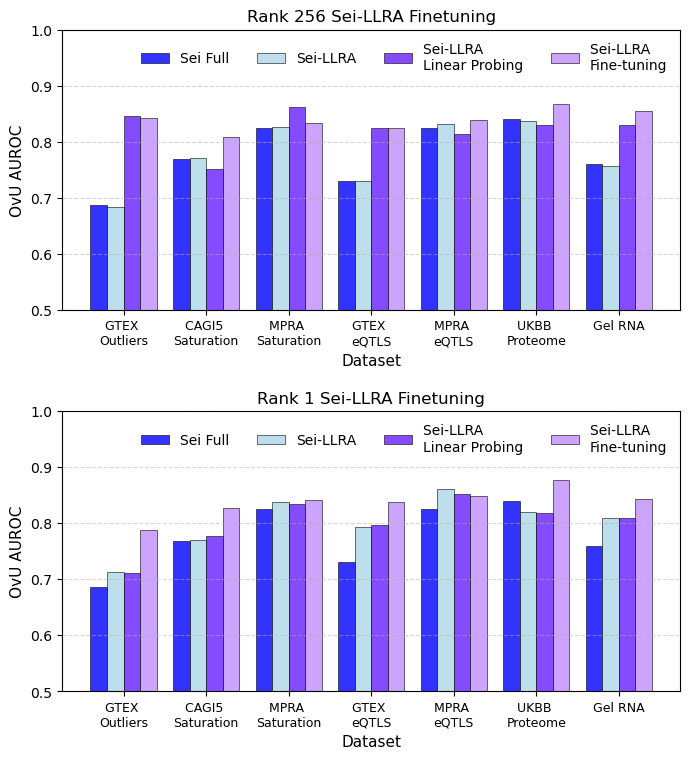


Comparison plot saved to ../figs/fig_sei_method_comparison.png

SUMMARY STATISTICS - Sei Model Performance by Method

RANK 1

Dataset              Full       LLRA       Probe      Fine-tune 
------------------------------------------------------------
GTEX 
Outliers       0.6869     0.7130     0.7119     0.7882    
CAGI5 
Saturation    0.7688     0.7700     0.7764     0.8270    
MPRA 
Saturation     0.8249     0.8372     0.8346     0.8419    
GTEX 
eQTLS          0.7305     0.7941     0.7969     0.8380    
MPRA 
eQTLS          0.8252     0.8615     0.8530     0.8483    
UKBB 
Proteome       0.8399     0.8196     0.8184     0.8764    
Gel RNA              0.7595     0.8099     0.8090     0.8436    

Mean AUROC:          0.7765     0.8008     0.8000     0.8376    

RANK 256

Dataset              Full       LLRA       Probe      Fine-tune 
------------------------------------------------------------
GTEX 
Outliers       0.6869     0.6843     0.8467     0.8416    
CAGI5 
Saturation    0.7

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Dataset mapping
caqtl_datasets = {
    "D": "GTEX_eqtl",
    "A": "GTEX_eqtl_outliers",
    "B": "CAGI5_saturation",
    "C": "MPRA_saturation",
    "E": "MPRA_eqtl",
    "F": "UKBB_proteome",
    "G": "Gel_RNA"
}

dataset_order = ["D", "A", "B", "C", "E", "F", "G"]
sorted_order = ["A", "B", "C", "D", "E", "F", "G"]

# Create sorted labels matching the sorted order
sorted_dataset_labels = {
    "A": "GTEX \nOutliers",
    "B": "CAGI5 \nSaturation",
    "C": "MPRA \nSaturation",
    "D": "GTEX \neQTLS",
    "E": "MPRA \neQTLS",
    "F": "UKBB \nProteome",
    "G": "Gel RNA"
}
sorted_labels = [sorted_dataset_labels[ds] for ds in sorted_order]

# Read the benchmark files
df_regular = pd.read_csv("benchmark_pai_seilora.tsv", sep="\t", index_col=0, header=0)
df_ft = pd.read_csv("benchmark_pai_all_ft_final2.tsv", sep="\t", index_col=0, header=0)

metric_key = "OvU"

# Colors for different training methods
method_colors = {
    "Full": "blue",
    "LLRA": "lightblue",
    "Probe": "#651EFF",  # light purple8E90FD
    "Fine-tune": "#C08EFD"  # darker purple
}

# Function to get AUROC values for each dataset
def get_auroc_values(df, model_name, datasets, metric):
    values = []
    for ds in datasets:
        col_name = f"{caqtl_datasets[ds]}_{metric}_promoter"
        if model_name in df.index and col_name in df.columns:
            values.append(float(df.loc[model_name, col_name]))
        else:
            values.append(0.0)
    return values

# Create two subplots (one for rank 1, one for rank 256)
fig, (ax2, ax1) = plt.subplots(2, 1, figsize=(7, 8.5))

ranks_to_plot = [1, 256]
axes = [ax1, ax2]

for rank, ax in zip(ranks_to_plot, axes):
    # Get data for each method using sorted order
    full_values = get_auroc_values(df_regular, "seilora_full_None_no_quant", sorted_order, metric_key)
    llra_values = get_auroc_values(df_regular, f"seilora_{rank}_None_no_quant", sorted_order, metric_key)
    probe_values = get_auroc_values(df_ft, f"seilora_{rank}_probe_quant", sorted_order, metric_key)
    ft_values = get_auroc_values(df_ft, f"seilora_{rank}_ft_head_quant", sorted_order, metric_key)
    
    # Setup for grouped bars
    x = np.arange(len(sorted_order))
    width = 0.2  # Width of each bar
    
    # Plot bars for each method
    ax.bar(x - 1.5*width, full_values, width, label='Sei Full', 
           color=method_colors['Full'], edgecolor='black', linewidth=0.5, alpha=0.8)
    ax.bar(x - 0.5*width, llra_values, width, label='Sei-LLRA', 
           color=method_colors['LLRA'], edgecolor='black', linewidth=0.5, alpha=0.8)
    ax.bar(x + 0.5*width, probe_values, width, label='Sei-LLRA \nLinear Probing', 
           color=method_colors['Probe'], edgecolor='black', linewidth=0.5, alpha=0.8)
    ax.bar(x + 1.5*width, ft_values, width, label='Sei-LLRA \nFine-tuning', 
           color=method_colors['Fine-tune'], edgecolor='black', linewidth=0.5, alpha=0.8)
    
    # Formatting
    ax.set_xlabel('Dataset\n', fontsize=11)
    ax.set_ylabel(f'{metric_key} AUROC', fontsize=11)
    ax.set_title(f'Rank {rank} Sei-LLRA Finetuning', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(sorted_labels, rotation=0, ha='center', fontsize=9)
    ax.set_ylim([0.5, 1.0])  # Typical AUROC range
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
    ax.legend(frameon=False, fontsize=10, loc="upper right", ncol=4)

# Add a single legend centered at the bottom for the entire figure
# handles, labels = ax1.get_legend_handles_labels()
# fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.08), 
#            ncol=4, frameon=False, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.18)  # Make room for the legend
plt.savefig('../figs/fig_sei_method_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nComparison plot saved to ../figs/fig_sei_method_comparison.png")

# Print summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS - Sei Model Performance by Method")
print("="*80)

for rank in ranks_to_plot:
    print(f"\n{'='*80}")
    print(f"RANK {rank}")
    print(f"{'='*80}")
    
    full_values = get_auroc_values(df_regular, "seilora_full_None_no_quant", sorted_order, metric_key)
    llra_values = get_auroc_values(df_regular, f"seilora_{rank}_None_no_quant", sorted_order, metric_key)
    probe_values = get_auroc_values(df_ft, f"seilora_{rank}_probe_quant", sorted_order, metric_key)
    ft_values = get_auroc_values(df_ft, f"seilora_{rank}_ft_head_quant", sorted_order, metric_key)
    
    print(f"\n{'Dataset':<20} {'Full':<10} {'LLRA':<10} {'Probe':<10} {'Fine-tune':<10}")
    print("-" * 60)
    for i, ds_label in enumerate(sorted_labels):
        print(f"{ds_label:<20} {full_values[i]:<10.4f} {llra_values[i]:<10.4f} {probe_values[i]:<10.4f} {ft_values[i]:<10.4f}")
    
    print(f"\n{'Mean AUROC:':<20} {np.mean(full_values):<10.4f} {np.mean(llra_values):<10.4f} {np.mean(probe_values):<10.4f} {np.mean(ft_values):<10.4f}")